# Grad-CAM

Gradient-weighted Class Activation Mapping

“For this image and this predicted class, where in the image did the CNN get its evidence?”

In [21]:
import tensorflow as tf

# The image that will be valuated. can be changed
img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/1280px-Penaeus_monodon.jpg"

# The model that will be evaluated
model = tf.keras.models.load_model("Fish_MN.keras")

# array of the classes as represented in the model
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]


## Compare with only the predicted class

What we see is:
* Original image
* Heatmap
* * Hot/warm colors (red/yellow) = regions that most influenced the model’s score for the chosen class
* * Cool/dark colors (blue/purple) = regions that contributed less
* Overlay heatmap on image
* * The heatmap is blended onto the original so you can interpret it visually.

Saved to images/shrimp_vs_predicted_class.png


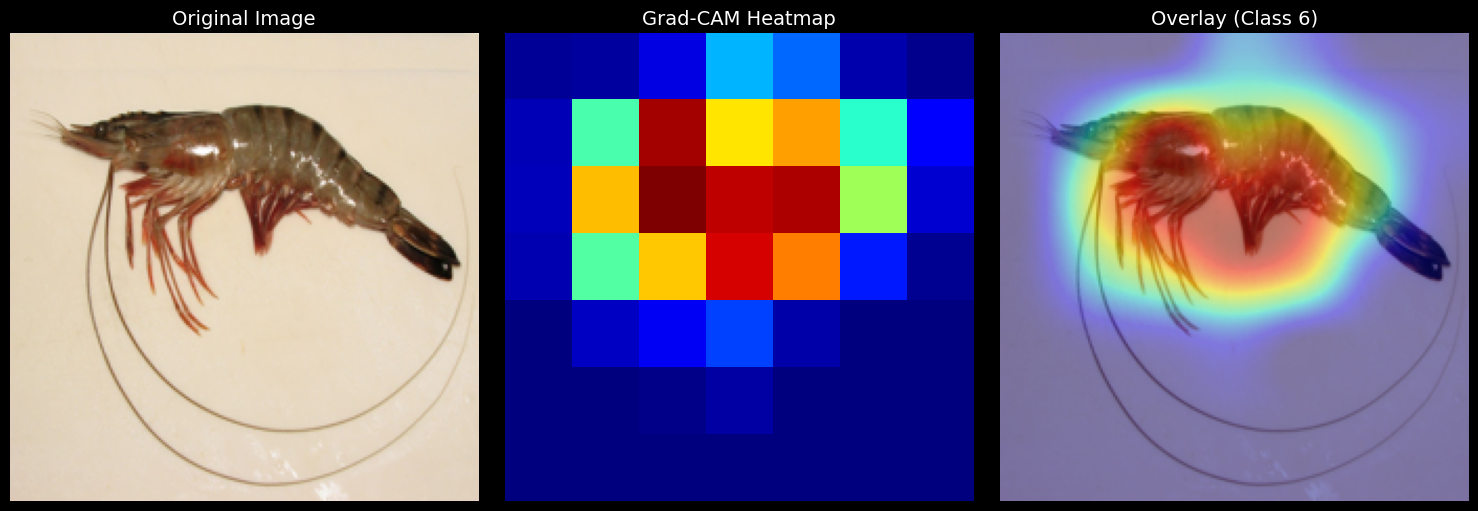

Predicted class index: 6


In [22]:
from gradcam_single_image import visualize_gradcam
img, heatmap, overlay_img, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    save_path="images/shrimp_vs_predicted_class.png"
)

print("Predicted class index:", class_idx)

## Compare with all 9 classes

Instead of just comparing with the top1 class we compare with all the 9 classes and see what the model lookls at for each class

Model predicts: Shrimp (class 6) with 99.12% confidence
Saved to images/shrimp_vs_9_classes.png


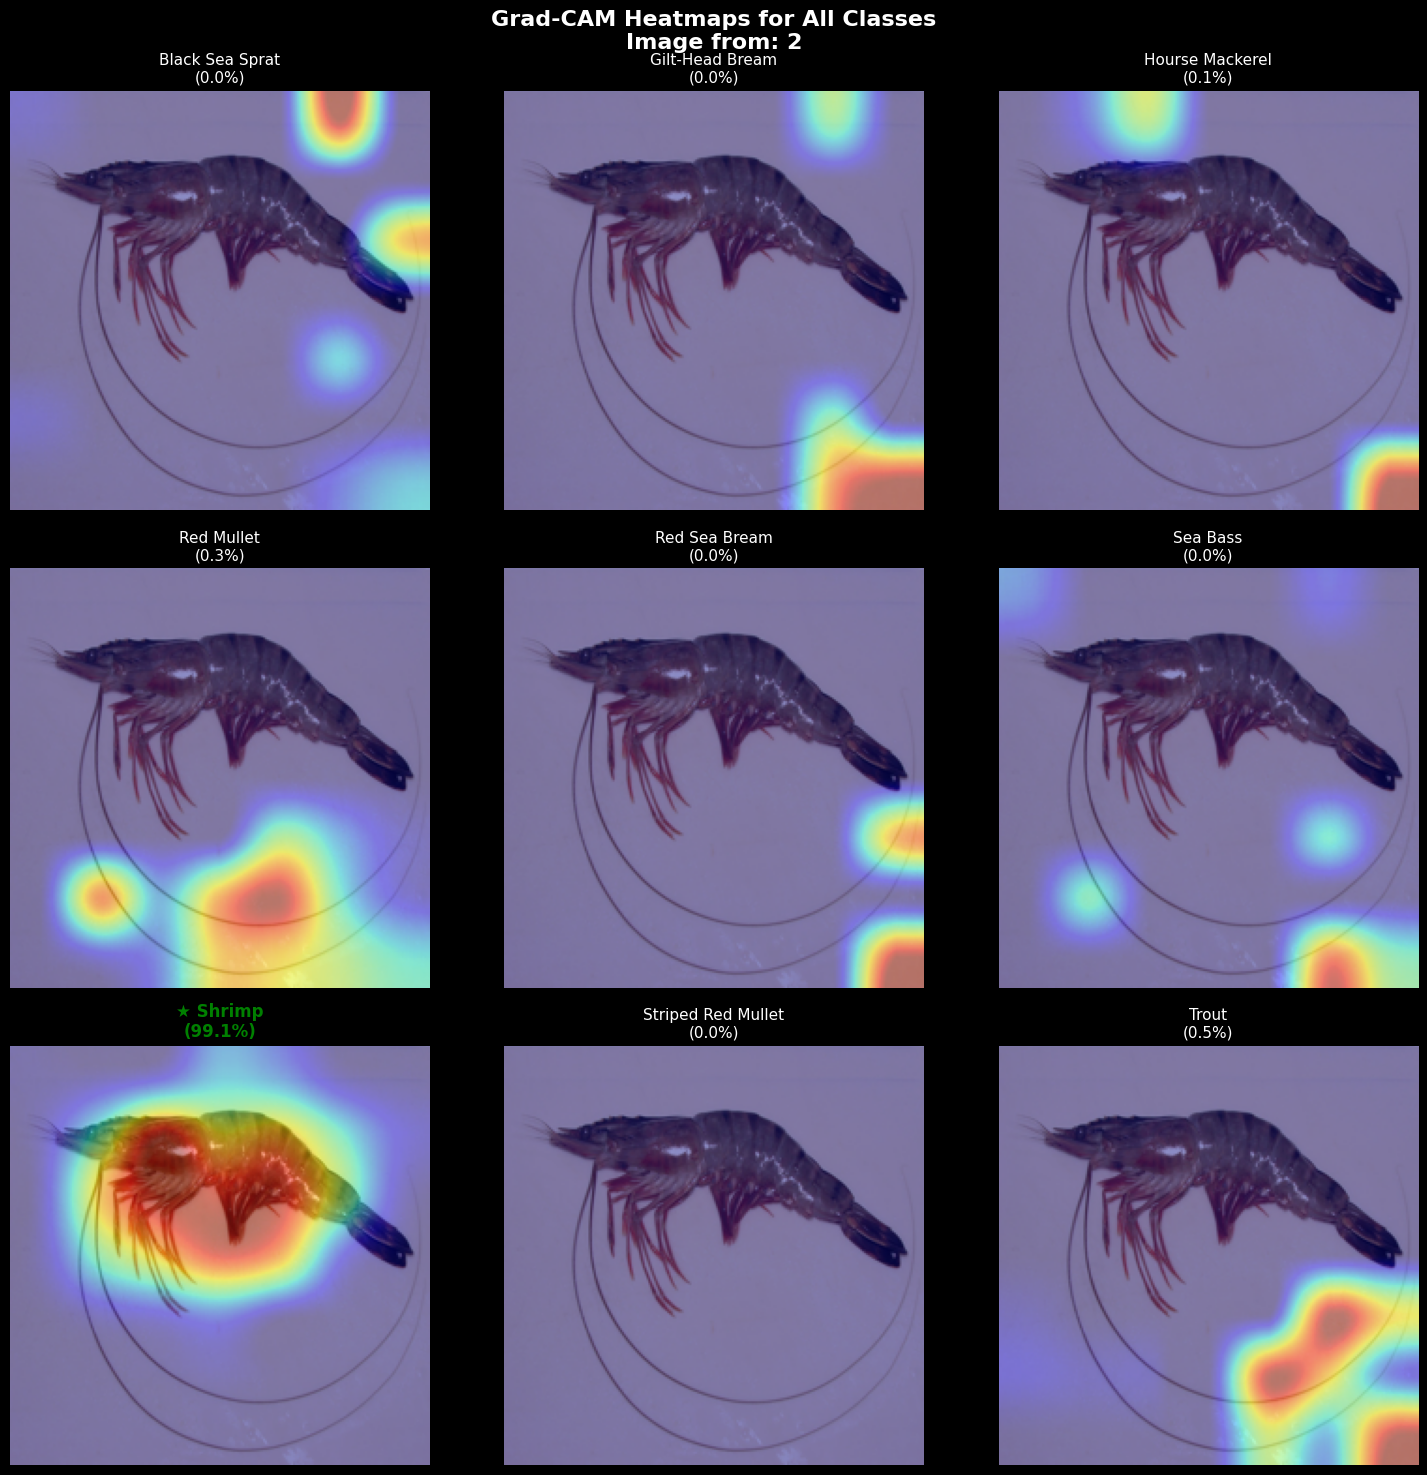


★ = Predicted class: Shrimp
Predicted: class 6
Confidence: 99.12%


In [23]:
from gradcam_all_classes import visualize_gradcam_all_classes

result = visualize_gradcam_all_classes(
    img_path=img_path,
    model=model,
    class_names=CLASS_NAMES,
    save_path='images/shrimp_vs_9_classes.png'
)

# Access the results
print(f"Predicted: class {result['predicted_class']}")
print(f"Confidence: {result['probabilities'][result['predicted_class']]:.2%}")
